In [112]:
import gzip, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
# ── Caricamento e costruzione della matrice enmo ─────────────
# CMI e' una LISTA di 4437 DataFrame (200 timestep x 13 canali).
# Estraggo solo il canale enmo da ognuno e lo metto in formato "largo":
# una riga = una finestra, le 200 colonne = i timestep (0..199).
with gzip.open("CMI_timeseries_dataset.pkl.gz", "rb") as f:
    CMI = pickle.load(f)

CHANNEL = "enmo"   # movimento complessivo; scelta univariata (vedi report)
X = np.vstack([ts[CHANNEL].values for ts in CMI])

df = pd.DataFrame(X, columns=[str(i) for i in range(X.shape[1])])
df.insert(0, "id", [ts["id"].iloc[0] for ts in CMI])          # a quale soggetto appartiene la finestra
df["sii_binary"] = [ts["sii_binary"].iloc[0] for ts in CMI]   # target: 0=non problematico, 1=problematico
time_series_cols = [str(i) for i in range(X.shape[1])]         # '0'..'199' = colonne temporali

df_time_series = df[time_series_cols]
print("shape:", df.shape, "| finestre:", len(df), "| timestep:", len(time_series_cols))
df.head()

shape: (4437, 202) | finestre: 4437 | timestep: 200


,id,0,1,2,3,4,5,6,7,8,...,191,192,193,194,195,196,197,198,199,sii_binary
0,2265,0.051424,0.062909,0.121546,0.084953,0.074157,0.065607,0.039383,0.030235,0.107227,...,2.133792e-02,2.167987e-02,2.117578e-02,2.925231e-02,2.334076e-02,4.377516e-02,2.164305e-02,1.739974e-02,2.592123e-02,0
1,51,0.009003,0.008412,0.008411,0.008508,0.008302,0.008168,0.008354,0.008443,0.008324,...,6.208354e-07,7.126397e-07,6.114244e-07,6.666051e-07,5.543696e-07,7.509920e-07,4.657374e-07,3.827214e-07,9.482039e-07,1
2,3042,0.018914,0.020372,0.010673,0.002617,0.039572,0.003114,0.018555,0.012977,0.029983,...,7.129729e-02,3.151401e-02,1.960694e-02,4.474784e-02,3.260628e-02,2.569457e-02,2.228737e-02,4.200678e-02,5.029766e-02,1
3,1647,0.026871,0.008789,0.003559,0.000000,0.019995,0.016514,0.001023,0.019502,0.029202,...,3.687440e-02,2.698474e-02,8.272605e-02,7.110153e-02,1.882067e-02,1.106635e-02,3.693391e-02,7.216558e-02,2.004158e-01,1
4,736,0.023046,0.014597,0.018531,0.012600,0.007322,0.004077,0.001821,0.004830,0.004752,...,1.070875e-01,6.057334e-02,8.677769e-02,1.066983e-01,2.641143e-02,1.451551e-02,6.151799e-02,2.569226e-02,2.645068e-02,0


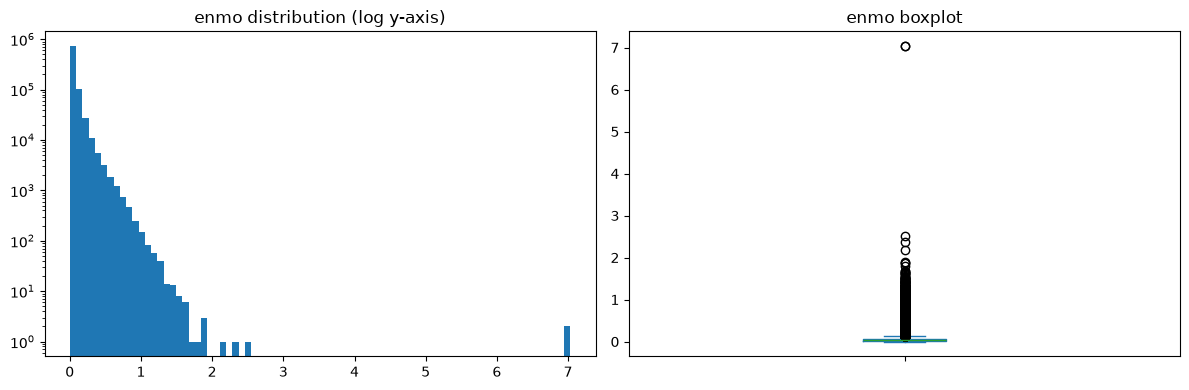

skew = 5.88


In [116]:
# ── Distribuzione globale del segnale enmo ───────────────────
# enmo e' fortemente asimmetrico (tanti valori piccoli = riposo,
# pochi valori alti = movimento intenso). Uso scala log sull'asse y
# dell'istogramma per rendere visibile la coda destra.
allvals = df[time_series_cols].values.ravel()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(allvals, bins=80, color='C0'); ax[0].set_yscale('log')
ax[0].set_title('enmo distribution (log y-axis)')
pd.Series(allvals).plot(kind='box', ax=ax[1]); ax[1].set_title('enmo boxplot')
plt.tight_layout()
plt.savefig('ts_enmo_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"skew = {pd.Series(allvals).skew():.2f}")   # conferma la forte asimmetria (~4-5)

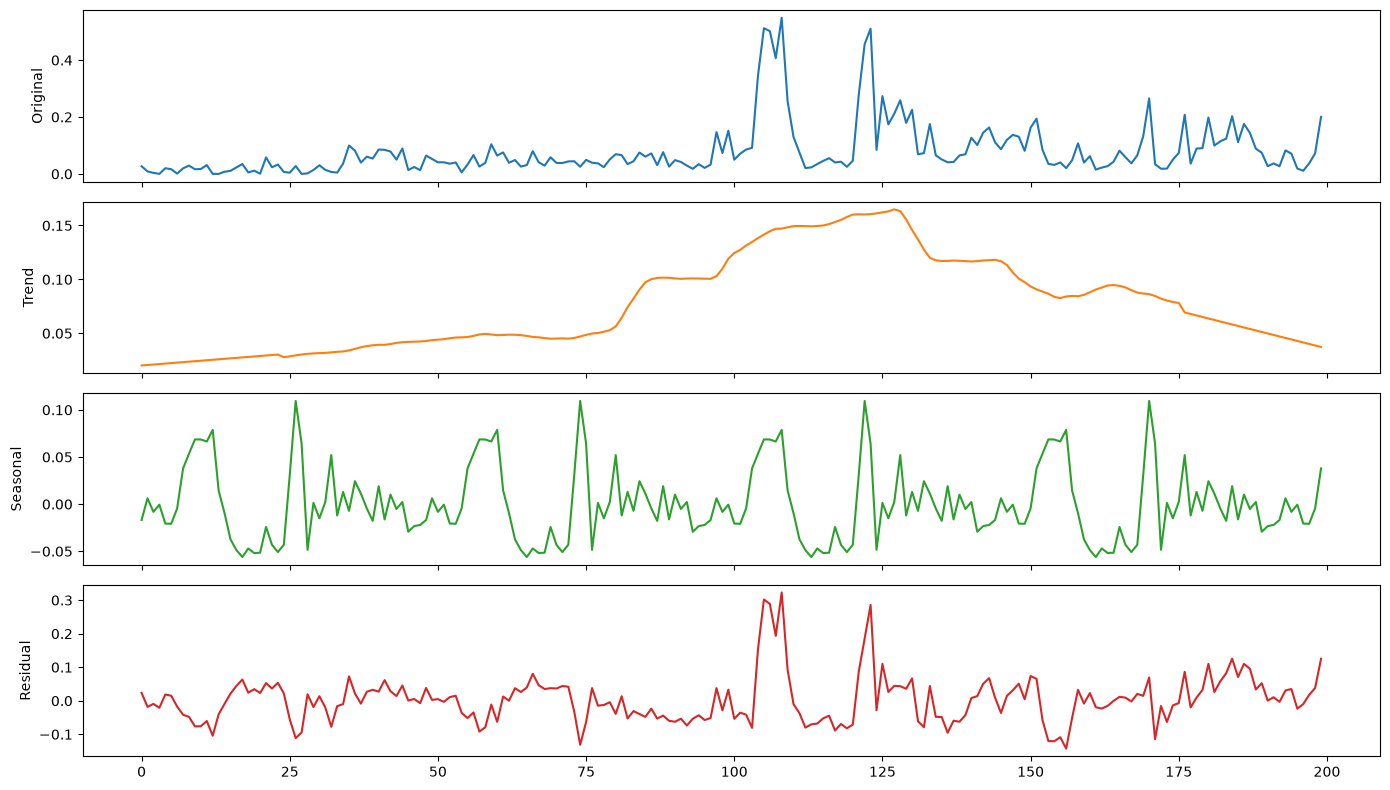

In [118]:
# ── Decomposizione stagionale di una serie di esempio ────────
# Scompone la serie in trend + stagionalita' + residuo.
# period=48 = un giorno intero (48 step da 30 min = 24h): cerca il
# ciclo giorno/notte. (period=24 sarebbe mezza giornata, meno interpretabile.)
from statsmodels.tsa.seasonal import seasonal_decompose

s = pd.Series(df.loc[3, time_series_cols].values.astype(float))
dec = seasonal_decompose(s, period=48, model='additive', extrapolate_trend='freq')

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(14, 8))
for a, comp, name, c in zip(axs, [dec.observed, dec.trend, dec.seasonal, dec.resid],
                            ['Original','Trend','Seasonal','Residual'], ['C0','C1','C2','C3']):
    a.plot(comp, color=c); a.set_ylabel(name)
plt.tight_layout()
plt.savefig('ts_seasonal_decompose.png', dpi=300, bbox_inches='tight')
plt.show()

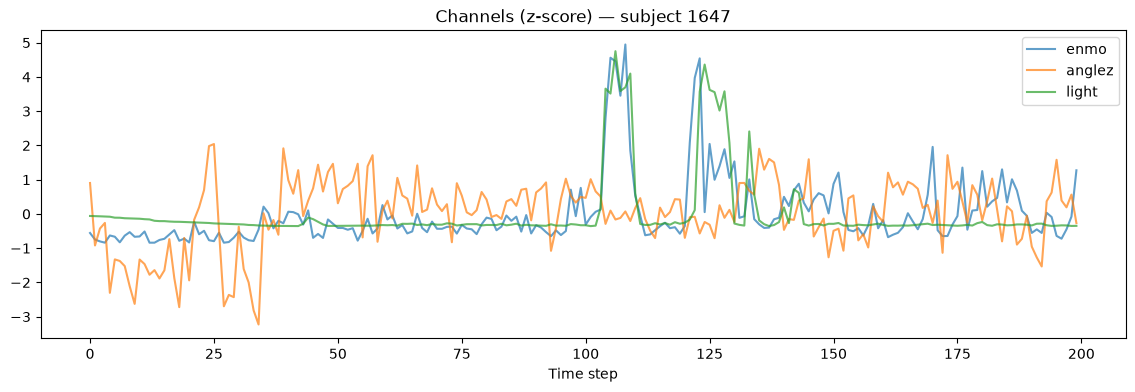

In [120]:
# ── Confronto multi-canale su una singola finestra (z-score) ──
# Mostra come enmo, anglez e light si muovono insieme nella stessa
# giornata. z-score per rendere confrontabili scale molto diverse
# (enmo ~[0,7], light ~[0,2600]). Solo esplorativo: l'analisi usa enmo.
sub = CMI[3]
plt.figure(figsize=(14, 4))
for ch, col in [('enmo','C0'), ('anglez','C1'), ('light','C2')]:
    z = (sub[ch].values - sub[ch].mean()) / (sub[ch].std() + 1e-9)
    plt.plot(z, color=col, alpha=0.7, label=ch)
plt.title(f"Channels (z-score) — subject {sub['id'].iloc[0]}")
plt.xlabel('Time step'); plt.legend()
plt.savefig('ts_channels_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

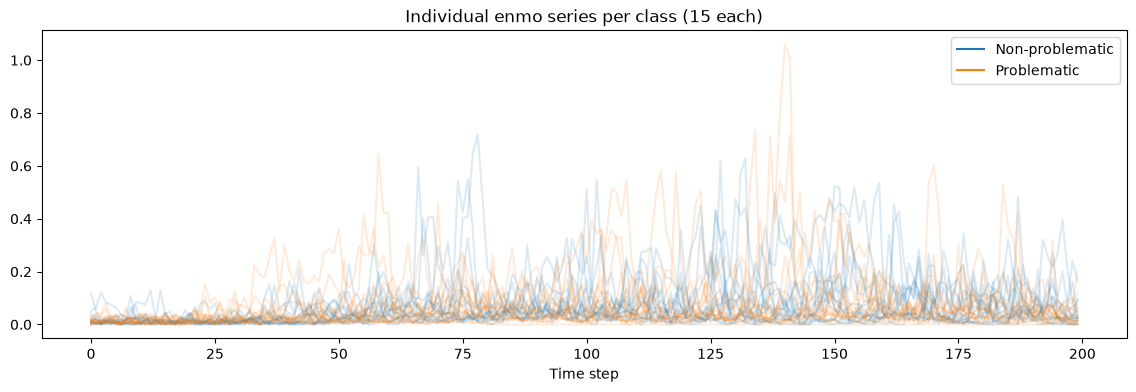

In [122]:
# ── Serie individuali per classe (15 esempi per classe) ──────
# Sovrappongo 15 serie grezze per ogni classe (trasparenza bassa)
# per vedere "a occhio" se problematici e non problematici hanno
# forme diverse.
plt.figure(figsize=(14, 4))
for cls, col in [(0, 'C0'), (1, 'C1')]:
    idxs = [i for i, l in enumerate(df['sii_binary']) if l == cls][:15]
    for i in idxs:
        plt.plot(df.loc[i, time_series_cols].values, color=col, alpha=0.15)
plt.plot([], [], color='C0', label='Non-problematic')   # voci di legenda "finte"
plt.plot([], [], color='C1', label='Problematic')
plt.title('Individual enmo series per class (15 each)')
plt.xlabel('Time step'); plt.legend()
plt.savefig('ts_individual_series_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

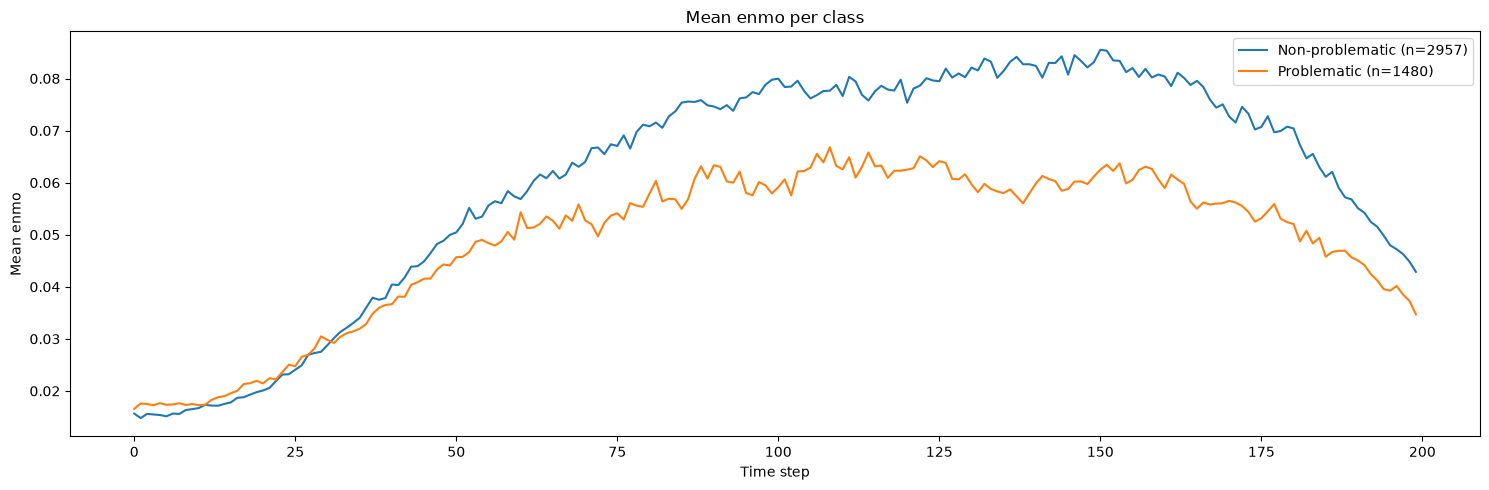

Global mean enmo per class:
sii_binary
0    0.060717
1    0.048867
dtype: float32


In [124]:
# ── Profilo medio per classe ─────────────────────────────────
# Media punto-per-punto di TUTTE le serie di ogni classe: mostra il
# "profilo tipico" di attivita' dei due gruppi lungo la giornata.
plt.figure(figsize=(15, 5))
for cls, lab in [(0, 'Non-problematic'), (1, 'Problematic')]:
    m = df.loc[df['sii_binary'] == cls, time_series_cols].mean(axis=0)
    plt.plot(range(len(m)), m.values, label=f"{lab} (n={(df['sii_binary']==cls).sum()})")
plt.title("Mean enmo per class"); plt.xlabel("Time step"); plt.ylabel("Mean enmo")
plt.legend(); plt.tight_layout()
plt.savefig('ts_mean_profile_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

print("Global mean enmo per class:")
print(df.groupby('sii_binary')[time_series_cols].mean().mean(axis=1))

In [126]:
# ── Controllo missing values ─────────────────────────────────
# Verifico esplicitamente che non ci siano NaN nei segnali prima di
# concludere che non serve imputazione (buona pratica: non darlo per scontato).
total_missing = df[time_series_cols].isnull().sum().sum()
print("Total missing values in signals:", total_missing)
# Nel dataset CMI non ci sono NaN sui canali -> nessuna imputazione necessaria.

Total missing values in signals: 0


In [100]:
# ── Anomaly detection con Hampel filter ──────────────────────
# Hampel: segnala un punto come anomalo se dista troppo dalla mediana
# LOCALE (finestra mobile), robusto perche' usa mediana+MAD invece di
# media+std (adatto a enmo, molto asimmetrico).
# Applico a TUTTE le serie e conto la frazione totale di punti anomali.
from sktime.transformations.series.outlier_detection import HampelFilter

annotator = HampelFilter(window_length=12, n_sigma=3, return_bool=True)

tot_points = 0
tot_anom = 0
for r in range(len(df)):
    serie = pd.Series(df.loc[r, time_series_cols].values.astype(float))
    labels = np.asarray(annotator.fit_transform(serie)).ravel()   # True = anomalo
    tot_points += len(labels)
    tot_anom += labels.sum()

print(f"Anomalous points (Hampel): {tot_anom} / {tot_points} ({tot_anom/tot_points*100:.2f}%)")
# Se la percentuale e' bassa -> segnale pulito, nessuna rimozione necessaria.

TypeError: C variable sklearn.utils._random.DEFAULT_SEED has wrong signature (expected __pyx_t_7sklearn_5utils_9_typedefs_uint32_t, got __pyx_t_7sklearn_5utils_9_typedefs_uint32_t const )

In [128]:
# ── Normalizzazione: z-score PER SERIE ───────────────────────
# Centro e scalo ogni serie sulla PROPRIA media/std, cosi' clustering e
# motif confrontano la FORMA (il pattern temporale) e non l'ampiezza
# assoluta (un bambino molto attivo vs uno sedentario).
ts_scaled = df[time_series_cols].sub(df[time_series_cols].mean(axis=1), axis=0)
ts_scaled = ts_scaled.div(df[time_series_cols].std(axis=1) + 1e-9, axis=0)
ts_scaled = pd.concat([df[['id']], ts_scaled, df[['sii_binary']]], axis=1)
ts_scaled.to_csv("cmi_ts_standardized.csv", index=False)
ts_scaled.head()

,id,0,1,2,3,4,5,6,7,8,...,191,192,193,194,195,196,197,198,199,sii_binary
0,2265,-0.092426,0.069239,0.894659,0.379554,0.227578,0.107217,-0.261930,-0.390700,0.693095,...,-0.515945,-0.511131,-0.518227,-0.404536,-0.487751,-0.200100,-0.511650,-0.571382,-0.451426,0
1,51,1.467157,1.317393,1.317065,1.341668,1.289497,1.255476,1.302516,1.325112,1.295121,...,-0.813782,-0.813759,-0.813785,-0.813771,-0.813799,-0.813749,-0.813822,-0.813843,-0.813699,1
2,3042,-0.607072,-0.586242,-0.724735,-0.839767,-0.312104,-0.832670,-0.612188,-0.691840,-0.449020,...,0.140897,-0.427154,-0.597171,-0.238193,-0.411558,-0.510248,-0.558898,-0.277332,-0.158949,1
3,1647,-0.556147,-0.746800,-0.801939,-0.839470,-0.628644,-0.665351,-0.828689,-0.633839,-0.531560,...,-0.450668,-0.554944,0.032791,-0.089778,-0.641026,-0.722787,-0.450040,-0.078558,1.273708,1
4,736,-0.519707,-0.635264,-0.581463,-0.662571,-0.734755,-0.779137,-0.809997,-0.768840,-0.769901,...,0.629673,-0.006472,0.351909,0.624350,-0.473683,-0.636376,0.006448,-0.483519,-0.473146,0


In [104]:
# ── Test di stazionarieta' (ADF) ─────────────────────────────
# ADF: p < 0.05 -> serie stazionaria (nessun trend). Testo un campione
# di 1/10 delle serie per velocita'; il risultato indica quante serie
# hanno bisogno di detrending.
from statsmodels.tsa.stattools import adfuller

def is_stationary(x):
    try:
        return adfuller(x)[1] < 0.05
    except Exception:
        return np.nan

frac = np.mean([is_stationary(ts_scaled.loc[r, time_series_cols].values.astype(float))
                for r in range(0, len(ts_scaled), 10)])   # campione 1/10 per velocita'
print(f"Fraction of stationary series (ADF, 10% sample): {frac:.2f}")

Fraction of stationary series (ADF, 10% sample): 0.84


In [106]:
# ── Detrend + deseason via medie mobili ──────────────────────
# Rimuovo trend e stagionalita' sottraendo due medie mobili successive.
# Rende le serie piu' stazionarie e confrontabili per i passi successivi.
def detrend_and_deseasonalize(ts, detrend_window=8, deseason_window=8):
    ts = pd.Series(ts)
    detr = ts - ts.rolling(window=detrend_window, min_periods=1, center=True).mean()
    deseas = detr - detr.rolling(window=deseason_window, min_periods=1, center=True).mean()
    return deseas.fillna(0).values

ts_transformed = pd.DataFrame(
    [detrend_and_deseasonalize(ts_scaled.loc[r, time_series_cols].values.astype(float))
     for r in range(len(ts_scaled))],
    columns=time_series_cols)
ts_transformed.insert(0, "id", ts_scaled["id"].values)
ts_transformed["sii_binary"] = ts_scaled["sii_binary"].values
ts_transformed.head()

,id,0,1,2,3,4,5,6,7,8,...,191,192,193,194,195,196,197,198,199,sii_binary
0,2265,-0.452462,-0.286491,0.598285,0.220495,0.182500,-0.190152,-0.475155,-0.334829,0.919863,...,-0.010609,0.054670,-0.055640,0.075791,-0.028624,0.248985,-0.069984,-0.150749,-0.013239,0
1,51,0.087017,-0.037121,-0.012609,0.014619,-0.043489,-0.047942,0.009052,0.054371,0.053022,...,-0.000022,0.000020,-0.000022,0.000014,-0.000001,0.000026,-0.000040,-0.000064,0.000083,1
2,3042,0.122127,-0.008207,-0.070661,-0.196140,0.341220,-0.214546,0.019167,-0.028789,0.188087,...,0.113410,-0.401853,-0.552942,0.144156,0.081041,0.002596,-0.092545,0.079303,0.229209,1
3,1647,0.195795,-0.036310,-0.106337,-0.106416,0.086042,0.055111,-0.122144,0.038836,0.064837,...,-0.277102,-0.147997,0.587829,0.543811,-0.144181,-0.658516,-0.495526,-0.057450,1.348879,1
4,736,0.041458,-0.029724,0.063242,0.023705,-0.030437,-0.026264,-0.135465,-0.057884,-0.054996,...,-0.231590,-0.508693,0.177926,0.674901,-0.341519,-0.372485,0.234905,-0.145211,0.162763,0


In [108]:
# ── Approssimazione simbolica SAX ────────────────────────────
# SAX riduce ogni serie (200 punti) a una "parola" di WORD_SIZE simboli
# su un alfabeto di ALPHABET livelli. Comprime i dati mantenendo la forma
# generale, utile per pattern/sequence mining.
from sktime.transformations.series.sax import SAX

WORD_SIZE, ALPHABET = 40, 6   # 200/40 = fattore di riduzione PAA pari a 5
sax = SAX(word_size=WORD_SIZE, alphabet_size=ALPHABET)

sax_rows = []
for r in range(len(ts_transformed)):
    x = ts_transformed.loc[r, time_series_cols].astype(float)
    out = sax.fit_transform(pd.DataFrame({0: x.values}))
    sax_rows.append(np.asarray(out).ravel())

sax_df = pd.DataFrame(sax_rows)
reconstructed = pd.concat([ts_scaled[['id']].reset_index(drop=True),
                           sax_df,
                           ts_scaled[['sii_binary']].reset_index(drop=True)], axis=1)
reconstructed.to_csv("cmi_ts_approx.csv", index=False)
print("SAX saved:", reconstructed.shape)
reconstructed.head()

SAX saved: (4437, 42)


,id,0,1,2,3,4,5,6,7,8,...,31,32,33,34,35,36,37,38,39,sii_binary
0,2265,3,2,3,2,3,2,2,3,2,...,3,2,3,3,2,2,3,2,2,0
1,51,3,3,2,2,3,2,3,3,2,...,2,2,2,2,2,2,2,2,2,1
2,3042,3,3,2,3,3,2,2,3,2,...,2,3,2,2,3,2,3,2,3,1
3,1647,3,3,2,3,3,2,2,3,3,...,3,2,2,2,3,3,3,3,2,1
4,736,3,3,2,3,2,2,2,3,3,...,3,2,3,3,3,2,3,2,2,0


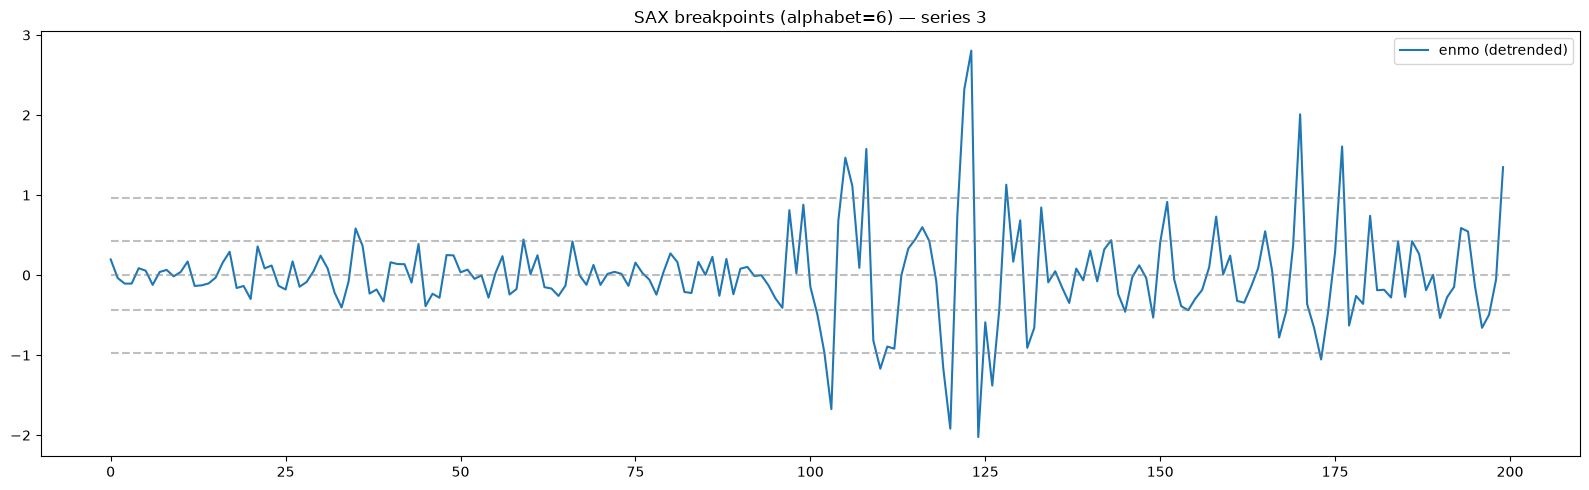

In [109]:
# ── Visualizzazione dei breakpoint SAX ───────────────────────
# Mostra una serie con le linee orizzontali dei breakpoint SAX:
# ogni fascia tra due linee corrisponde a un simbolo dell'alfabeto.
import scipy.stats

r = 3
x = ts_transformed.loc[r, time_series_cols].astype(float)
bin_edges = scipy.stats.norm.ppf(np.linspace(0, 1, ALPHABET + 1)[1:-1])

plt.figure(figsize=(16, 5))
plt.plot(x.values, label='enmo (detrended)')
for b in bin_edges:
    plt.hlines(b, 0, len(x), color='gray', linestyle='--', alpha=0.5)
plt.title(f"SAX breakpoints (alphabet={ALPHABET}) — series {r}")
plt.legend(); plt.tight_layout()
plt.savefig('ts_sax_breakpoints.png', dpi=300, bbox_inches='tight')
plt.show()